In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / 'data').exists():
    raise FileNotFoundError('Não foi possível localizar a raiz do projeto.')

for candidate in [
    PROJECT_ROOT / 'code',
    PROJECT_ROOT / 'code' / 'tmdb',
]:
    if candidate.exists() and str(candidate.resolve()) not in sys.path:
        sys.path.append(str(candidate.resolve()))

import unicodedata
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from tmdb_feature_enrichment_utils import (
    DEFAULT_TOP_CAST_LABELS,
    DEFAULT_TOP_COMPANY_LABELS,
    DEFAULT_TOP_DIRECTOR_LABELS,
    TMDB_ADDITIONAL_METADATA_PATH,
    TMDB_EXTENDED_PROCESSED_DATA_PATH,
    merge_tmdb_additional_features_with_processed_dataset,
)

/home/gabriel/Faculdade/Matérias/ML/UFSJ_Aprendizado_Maquina_TP1/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# **Análise e Pré-processamento dos Metadados Adicionais do TMDB**

Este notebook exerce para os metadados adicionais o mesmo papel que o `02_analysis_and_preprocessing.ipynb` exerce para a base original. Ele carrega o cache bruto criado no notebook `03`, verifica cobertura e consistência, explora as novas variáveis e gera a versão processada estendida que será usada nos experimentos seguintes.

A preocupação aqui é separar claramente três camadas:

- coleta bruta dos metadados adicionais no notebook `03`;
- análise e codificação desses novos atributos neste notebook `04`;
- integração posterior com sinais externos adicionais e modelagem na pasta `code/revenue`.


In [2]:
PROCESSED_DATA_INPUT = PROJECT_ROOT / 'data' / 'TMDB_movies_processed.csv'
TMDB_METADATA_INPUT = TMDB_ADDITIONAL_METADATA_PATH
TMDB_EXTENDED_PROCESSED_OUTPUT = TMDB_EXTENDED_PROCESSED_DATA_PATH

TOP_CAST_LABELS = DEFAULT_TOP_CAST_LABELS
TOP_DIRECTOR_LABELS = DEFAULT_TOP_DIRECTOR_LABELS
TOP_COMPANY_LABELS = DEFAULT_TOP_COMPANY_LABELS

IMAGES_DIR = PROJECT_ROOT / 'code' / 'tmdb' / 'images'
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

ARTICLE_NOTEBOOK_DPI = 170
ARTICLE_EXPORT_DPI = 320
ARTICLE_FIGURE_SIZES = {
    'axis_label': 22,
    'tick': 18,
    'annotation': 18,
}
ARTICLE_FIGURE_RC = {
    'axes.labelsize': ARTICLE_FIGURE_SIZES['axis_label'],
    'xtick.labelsize': ARTICLE_FIGURE_SIZES['tick'],
    'ytick.labelsize': ARTICLE_FIGURE_SIZES['tick'],
    'figure.dpi': ARTICLE_NOTEBOOK_DPI,
    'savefig.dpi': ARTICLE_EXPORT_DPI,
}

## **Novos atributos analisados**

O arquivo `data/TMDB_movies_additional_metadata.csv` traz, para cada filme, variáveis de produção e de calendário que não estavam presentes na base processada original. Entre os atributos principais, destacam-se:

- `release_date`, `release_year`, `release_month`, `release_quarter` e `release_period`;
- `director_name`;
- `top_billed_cast`;
- `production_company_names` e `main_production_company`;
- `production_company_count` e `cast_member_count`;
- `is_summer_release` e `is_holiday_release`.

Como parte do pré-processamento, essas variáveis são verificadas, convertidas para tipos adequados e então codificadas em uma base estendida pronta para regressão.

In [3]:
def split_pipe_values(value):
    if pd.isna(value):
        return []
    return [item.strip() for item in str(value).split('|') if item.strip()]


def build_image_path(filename):
    normalized = unicodedata.normalize('NFKD', filename).encode('ascii', 'ignore').decode('ascii')
    safe_name = ''.join(char.lower() if char.isalnum() or char in {'_', '.', '-'} else '_' for char in normalized)
    safe_name = '_'.join(part for part in safe_name.split('_') if part)
    return IMAGES_DIR / safe_name


def save_current_figure(filename, dpi=ARTICLE_EXPORT_DPI):
    image_path = build_image_path(filename)
    plt.savefig(image_path, dpi=dpi, bbox_inches='tight')
    return image_path


def apply_article_figure_theme():
    sns.set_theme(style='whitegrid', context='talk', rc=ARTICLE_FIGURE_RC)


def show_and_save_current_figure(filename, notebook_title=None, dpi=ARTICLE_EXPORT_DPI):
    if notebook_title:
        print(f'Figura: {notebook_title}')
    image_path = save_current_figure(filename, dpi=dpi)
    plt.show()
    plt.close()
    return image_path


def plot_top_counts(series, title, xlabel, filename, top_n=15, color=None):
    non_empty_series = series.dropna().astype(str)
    non_empty_series = non_empty_series[non_empty_series.str.strip() != '']
    if non_empty_series.empty:
        print(f'Sem dados para: {title}')
        return pd.Series(dtype='int64')

    apply_article_figure_theme()
    counts = non_empty_series.value_counts().head(top_n).sort_values()
    height = max(6.4, 0.52 * len(counts) + 3.2)
    plt.figure(figsize=(13.2, height))
    palette = [color] * len(counts) if color else sns.color_palette('crest', len(counts))

    ax = sns.barplot(
        x=counts.values,
        y=counts.index,
        palette=palette,
        orient='h',
        edgecolor='#243746',
        linewidth=0.8,
    )

    ax.set_xlabel(xlabel, fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=12)
    ax.set_ylabel('', fontsize=ARTICLE_FIGURE_SIZES['axis_label'])
    ax.tick_params(axis='x', labelsize=ARTICLE_FIGURE_SIZES['tick'])
    ax.tick_params(axis='y', labelsize=ARTICLE_FIGURE_SIZES['tick'])
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('semibold')

    ax.grid(axis='x', linestyle='--', alpha=0.28)
    sns.despine(ax=ax, left=False, bottom=False)

    max_value = counts.max() if len(counts) else 0
    for index, value in enumerate(counts.values):
        ax.text(
            value + max(0.5, max_value * 0.01),
            index,
            str(int(value)),
            va='center',
            ha='left',
            fontsize=ARTICLE_FIGURE_SIZES['annotation'],
            fontweight='semibold',
            color='#243746',
        )

    plt.tight_layout()
    show_and_save_current_figure(filename, notebook_title=title)
    return counts


def plot_numeric_distribution(df, column, title, xlabel, filename, bins=24, color=None):
    valid_df = df.loc[df[column].notna()].copy()
    if valid_df.empty:
        print(f'Sem dados numéricos para: {column}')
        return

    apply_article_figure_theme()
    plt.figure(figsize=(13, 7.4))

    ax = sns.histplot(
        valid_df[column],
        bins=bins,
        kde=True,
        color=color or '#4c6a92',
        edgecolor='white',
        linewidth=0.9,
        alpha=0.9,
        line_kws={'linewidth': 2.4, 'color': '#8c1c13'},
    )

    ax.set_xlabel(xlabel, fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=12)
    ax.set_ylabel('Número de Filmes', fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=12)
    ax.tick_params(axis='x', labelsize=ARTICLE_FIGURE_SIZES['tick'])
    ax.tick_params(axis='y', labelsize=ARTICLE_FIGURE_SIZES['tick'])
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('semibold')
    ax.grid(True, linestyle='--', alpha=0.28)
    sns.despine(ax=ax)

    plt.tight_layout()
    show_and_save_current_figure(filename, notebook_title=title)

In [4]:
metadata_df = pd.read_csv(TMDB_METADATA_INPUT)
processed_df = pd.read_csv(PROCESSED_DATA_INPUT)

print(f'Base de metadados adicionais: {metadata_df.shape}')
print(f'Base processada original: {processed_df.shape}')
display(metadata_df.head())

Base de metadados adicionais: (6918, 19)
Base processada original: (6918, 73)


,id_tmdb,title,tmdb_title,release_date,release_year,release_month,release_quarter,release_period,is_summer_release,is_holiday_release,director_name,top_billed_cast,production_company_names,main_production_company,production_company_count,cast_member_count,tmdb_fetch_status,tmdb_http_status,tmdb_error
0,5,Four Rooms,Four Rooms,1995-12-09,1995,12,Q4,verao,0,1,Allison Anders,Tim Roth|Jennifer Beals|David Proval,Miramax|A Band Apart,Miramax,2,28,ok,200,NaN
1,6,Judgment Night,Judgment Night,1993-10-15,1993,10,Q4,primavera,0,0,Stephen Hopkins,Emilio Estevez|Cuba Gooding Jr.|Denis Leary,Largo Entertainment|JVC|Universal Pictures,Largo Entertainment,3,31,ok,200,NaN
2,11,Star Wars,Star Wars,1977-05-25,1977,5,Q2,outono,1,0,George Lucas,Mark Hamill|Harrison Ford|Carrie Fisher,Lucasfilm Ltd.,Lucasfilm Ltd.,1,104,ok,200,NaN
3,12,Finding Nemo,Finding Nemo,2003-05-30,2003,5,Q2,outono,1,0,Andrew Stanton,Albert Brooks|Ellen DeGeneres|Alexander Gould,Pixar,Pixar,1,68,ok,200,NaN
4,13,Forrest Gump,Forrest Gump,1994-06-23,1994,6,Q2,inverno,1,0,Robert Zemeckis,Tom Hanks|Robin Wright|Gary Sinise,Paramount Pictures|The Steve Tisch Company|Wen...,Paramount Pictures,3,146,ok,200,NaN


## **Consistência e preparação inicial**

Antes da análise propriamente dita, a base adicional passa por uma limpeza leve: remoção de duplicatas por `id_tmdb`, padronização de campos textuais vazios, conversão de datas e coerção dos campos numéricos derivados da API.

Essa preparação é suficiente para a análise exploratória e mantém a responsabilidade da codificação final concentrada na mesma função utilitária usada no restante do pipeline.

In [5]:
analysis_df = metadata_df.drop_duplicates(subset='id_tmdb', keep='last').copy()

text_columns = [
    'title',
    'tmdb_title',
    'release_quarter',
    'release_period',
    'director_name',
    'top_billed_cast',
    'production_company_names',
    'main_production_company',
    'tmdb_fetch_status',
    'tmdb_error',
]
for column in text_columns:
    analysis_df[column] = analysis_df[column].fillna('').astype(str).str.strip()

numeric_columns = [
    'release_year',
    'release_month',
    'production_company_count',
    'cast_member_count',
    'is_summer_release',
    'is_holiday_release',
    'tmdb_http_status',
]
for column in numeric_columns:
    analysis_df[column] = pd.to_numeric(analysis_df[column], errors='coerce')

analysis_df['release_date'] = pd.to_datetime(analysis_df['release_date'], errors='coerce')
analysis_df['top_cast_list'] = analysis_df['top_billed_cast'].apply(split_pipe_values)
analysis_df['company_list'] = analysis_df['production_company_names'].apply(split_pipe_values)

print(f'Linhas após remover duplicatas por id_tmdb: {analysis_df.shape[0]}')
display(
    analysis_df[
        [
            'id_tmdb', 'title', 'release_date', 'director_name', 'top_billed_cast',
            'production_company_names', 'production_company_count', 'cast_member_count',
            'tmdb_fetch_status'
        ]
    ].head()
)

Linhas após remover duplicatas por id_tmdb: 6918


,id_tmdb,title,release_date,director_name,top_billed_cast,production_company_names,production_company_count,cast_member_count,tmdb_fetch_status
0,5,Four Rooms,1995-12-09,Allison Anders,Tim Roth|Jennifer Beals|David Proval,Miramax|A Band Apart,2,28,ok
1,6,Judgment Night,1993-10-15,Stephen Hopkins,Emilio Estevez|Cuba Gooding Jr.|Denis Leary,Largo Entertainment|JVC|Universal Pictures,3,31,ok
2,11,Star Wars,1977-05-25,George Lucas,Mark Hamill|Harrison Ford|Carrie Fisher,Lucasfilm Ltd.,1,104,ok
3,12,Finding Nemo,2003-05-30,Andrew Stanton,Albert Brooks|Ellen DeGeneres|Alexander Gould,Pixar,1,68,ok
4,13,Forrest Gump,1994-06-23,Robert Zemeckis,Tom Hanks|Robin Wright|Gary Sinise,Paramount Pictures|The Steve Tisch Company|Wen...,3,146,ok


## **Cobertura e qualidade da coleta**

Aqui são inspecionados os status de retorno do enriquecimento adicional e a quantidade de valores ausentes nos principais campos. Essa checagem é importante porque parte da utilidade dessas novas variáveis depende da cobertura efetiva do TMDB sobre o conjunto final de filmes.

In [6]:
status_counts = (
    analysis_df['tmdb_fetch_status']
    .replace('', pd.NA)
    .fillna('ausente')
    .value_counts(dropna=False)
    .rename_axis('tmdb_fetch_status')
    .reset_index(name='frequencia')
)
display(status_counts)

missing_summary = analysis_df[
    [
        'release_date',
        'release_year',
        'director_name',
        'top_billed_cast',
        'production_company_names',
        'main_production_company',
    ]
].isna().sum().to_frame(name='n_missing')
missing_summary['pct_missing'] = missing_summary['n_missing'] / len(analysis_df)
display(missing_summary.sort_values('pct_missing', ascending=False))

,tmdb_fetch_status,frequencia
0,ok,6918


,n_missing,pct_missing
release_date,0,0.0
release_year,0,0.0
director_name,0,0.0
top_billed_cast,0,0.0
production_company_names,0,0.0
main_production_company,0,0.0


## **Calendário de estreia**

As variáveis de período de estreia são relevantes porque ajudam a capturar efeitos sazonais de lançamento. Nesta seção, são observadas a distribuição dos períodos, a evolução dos anos de lançamento e a presença de janelas comerciais específicas, como verão e fim de ano.

,release_period,frequencia
0,primavera,1936
1,inverno,1750
2,verao,1683
3,outono,1549


/tmp/ipykernel_7198/2171110284.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


Figura: Distribuição do Período de Estreia


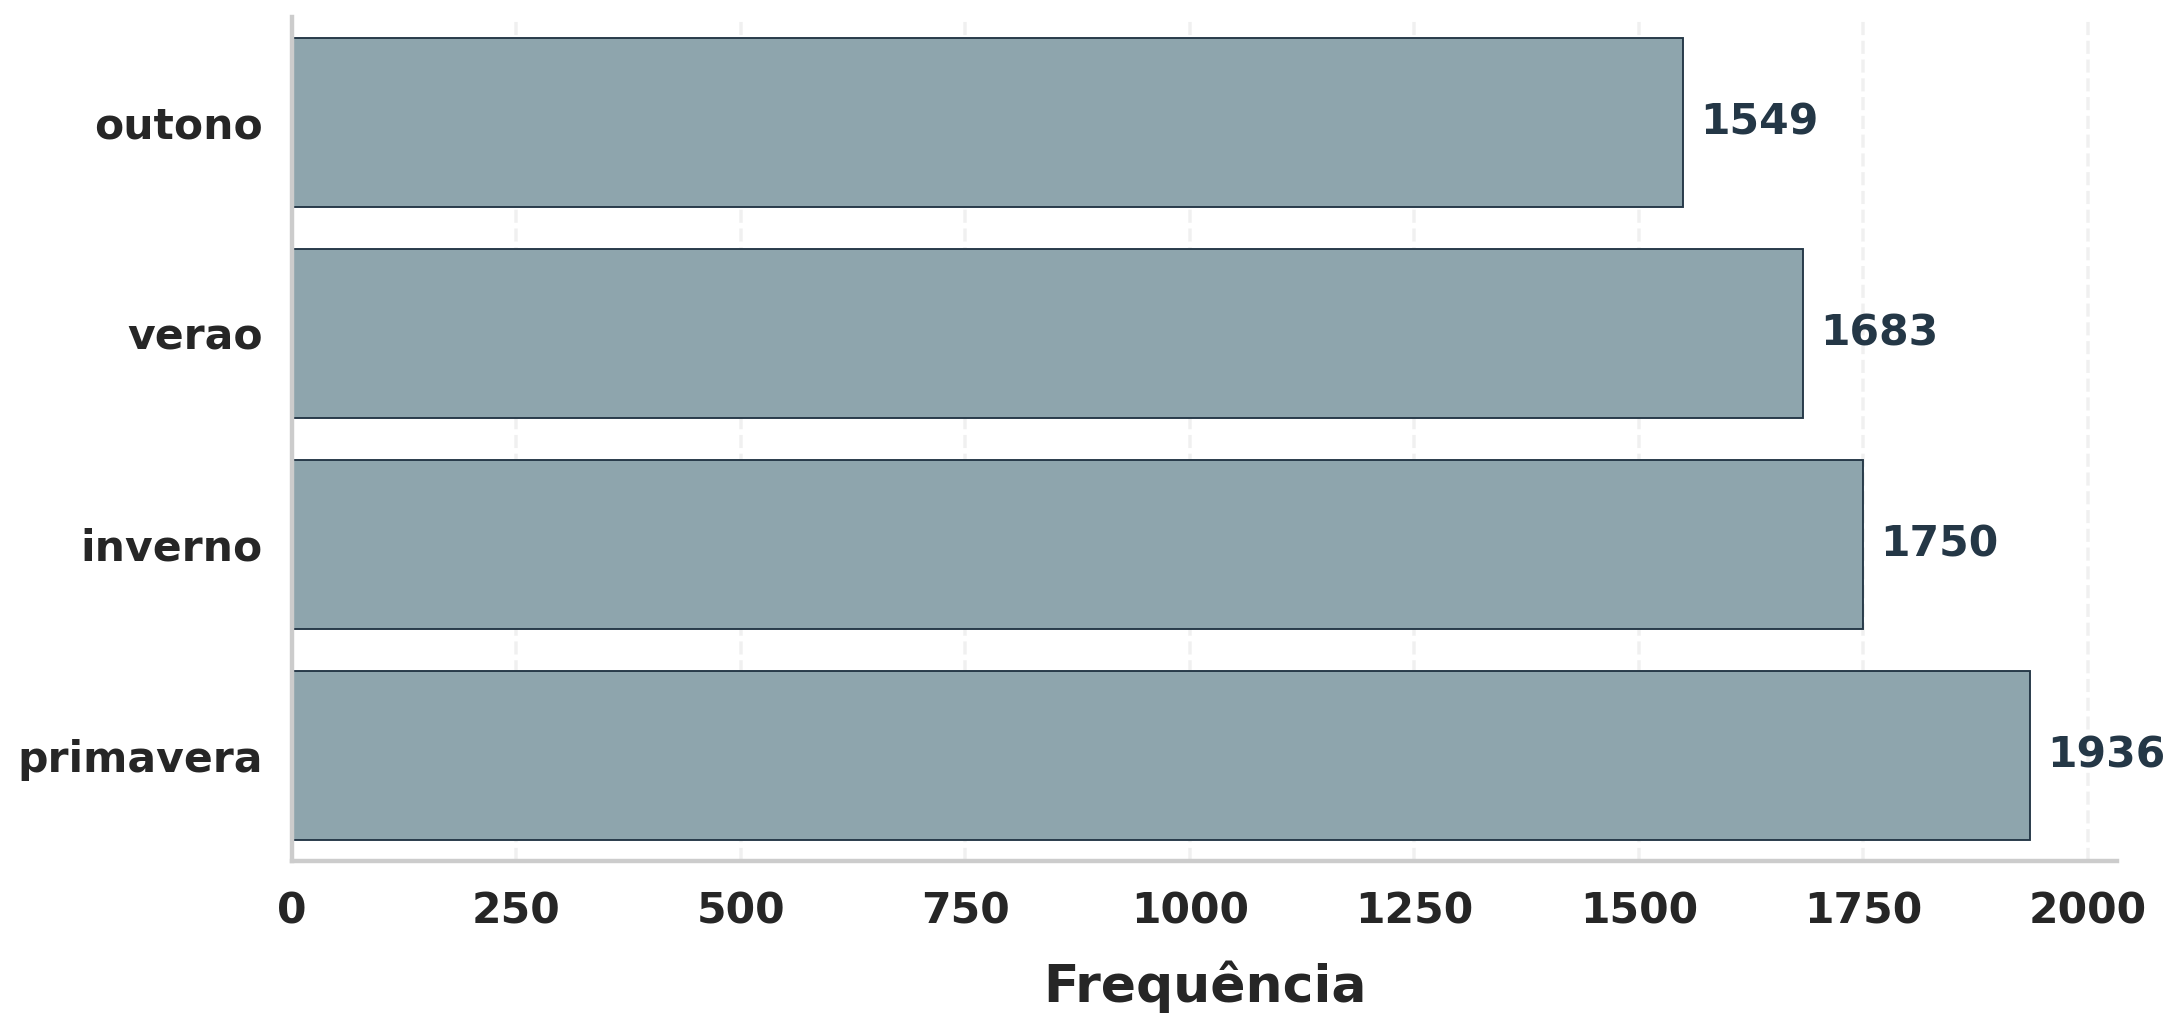

,count,mean,std,min,25%,50%,75%,max
release_year,6918.0,2003.849234,16.324754,1915.0,1996.0,2007.0,2015.0,2025.0


Figura: Distribuição do Ano de Estreia


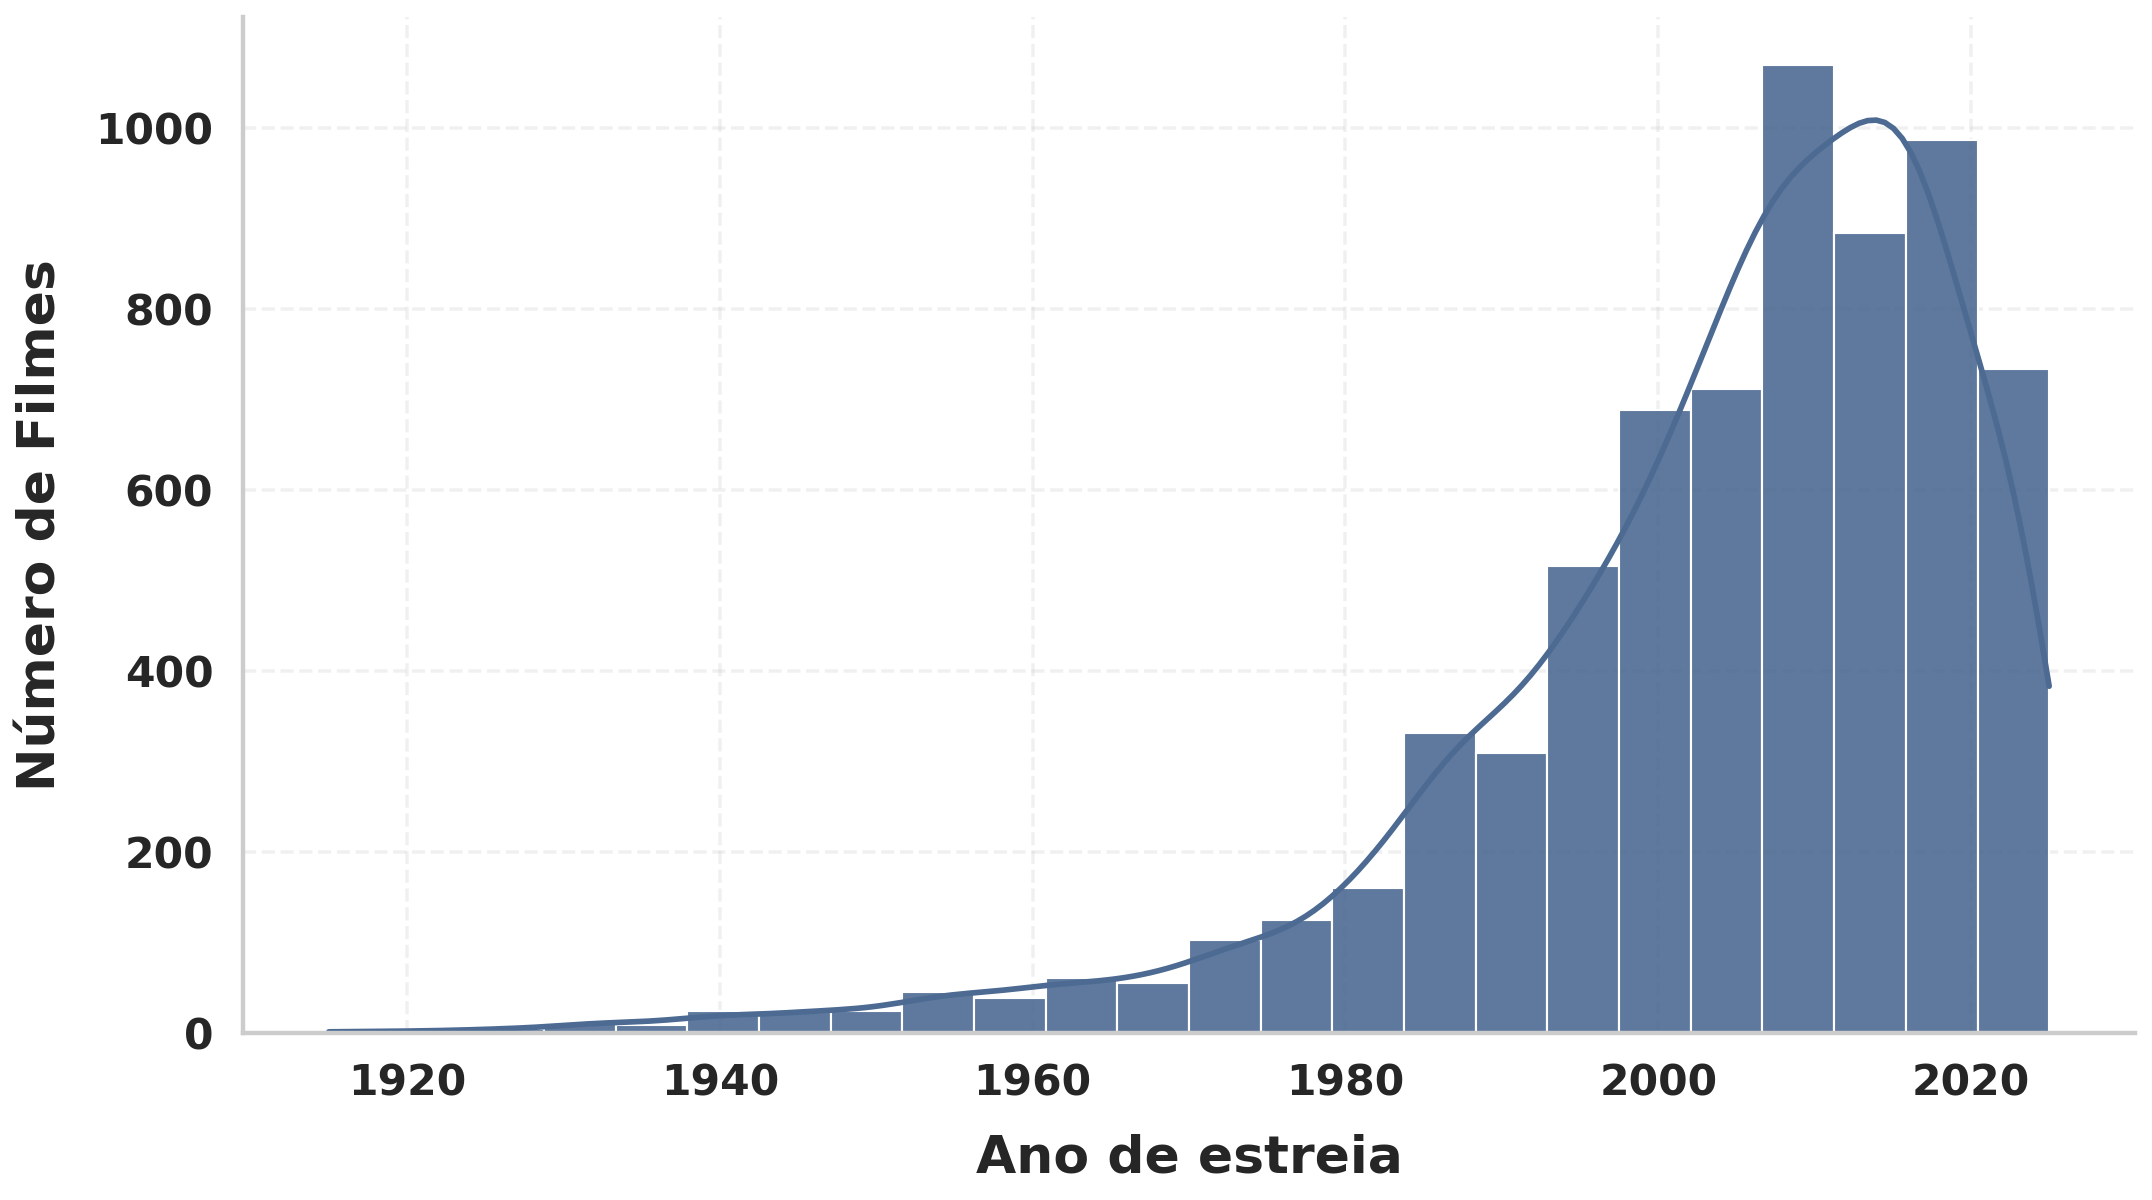

,frequencia
is_summer_release,2244
is_holiday_release,1323


In [7]:
release_period_series = analysis_df['release_period'].replace('', pd.NA).fillna('desconhecido')
release_period_counts = release_period_series.value_counts().rename_axis('release_period').reset_index(name='frequencia')
display(release_period_counts)

plot_top_counts(
    release_period_series,
    title='Distribuição do Período de Estreia',
    xlabel='Frequência',
    filename='04_release_period_distribution.png',
    top_n=10,
    color='#89a8b2',
)

release_year_df = analysis_df.loc[analysis_df['release_year'].notna(), ['release_year']].copy()
if not release_year_df.empty:
    release_year_df['release_year'] = release_year_df['release_year'].astype(int)
    display(release_year_df['release_year'].describe().to_frame().T)
    plot_numeric_distribution(
        release_year_df,
        column='release_year',
        title='Distribuição do Ano de Estreia',
        xlabel='Ano de estreia',
        filename='04_release_year_distribution.png',
    )

season_flags = analysis_df[['is_summer_release', 'is_holiday_release']].fillna(0).astype(int).sum().to_frame(name='frequencia')
display(season_flags)

## **Estrutura de elenco e empresas de produção**

As novas colunas de contagem ajudam a medir a complexidade de créditos e de produção, enquanto as colunas textuais permitem examinar quais diretores, nomes de elenco e empresas aparecem com maior frequência na base.

,count,mean,std,min,25%,50%,75%,max
production_company_count,6918.0,3.521683,2.159608,1.0,2.0,3.0,4.0,25.0
cast_member_count,6918.0,44.154814,28.253518,0.0,25.0,38.0,56.0,396.0
is_summer_release,6918.0,0.324371,0.468173,0.0,0.0,0.0,1.0,1.0
is_holiday_release,6918.0,0.191240,0.393306,0.0,0.0,0.0,0.0,1.0


Figura: Distribuição da Quantidade de Empresas de Produção


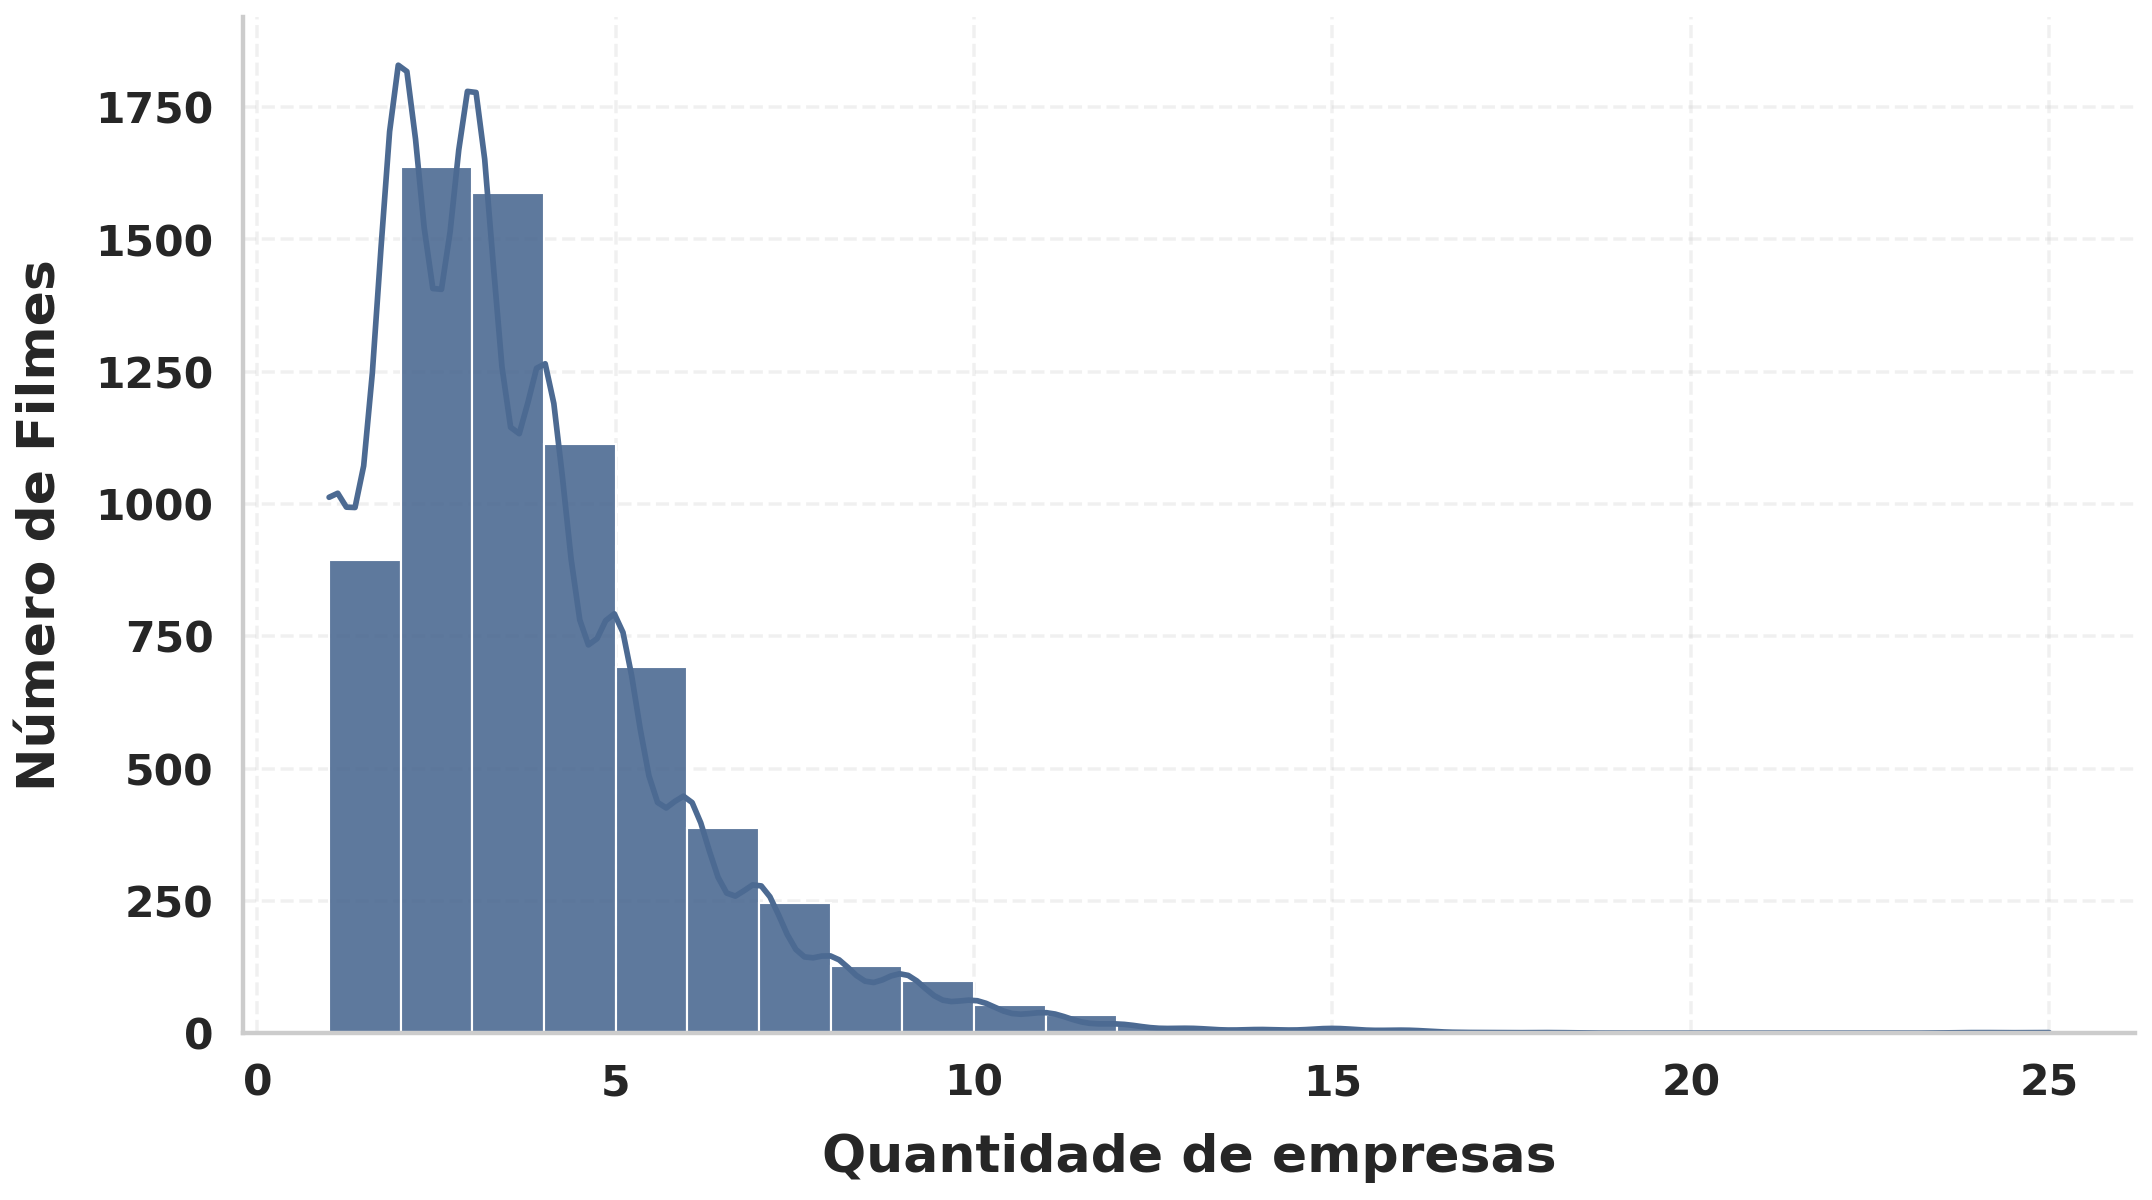

Figura: Distribuição da Quantidade de Créditos no Elenco


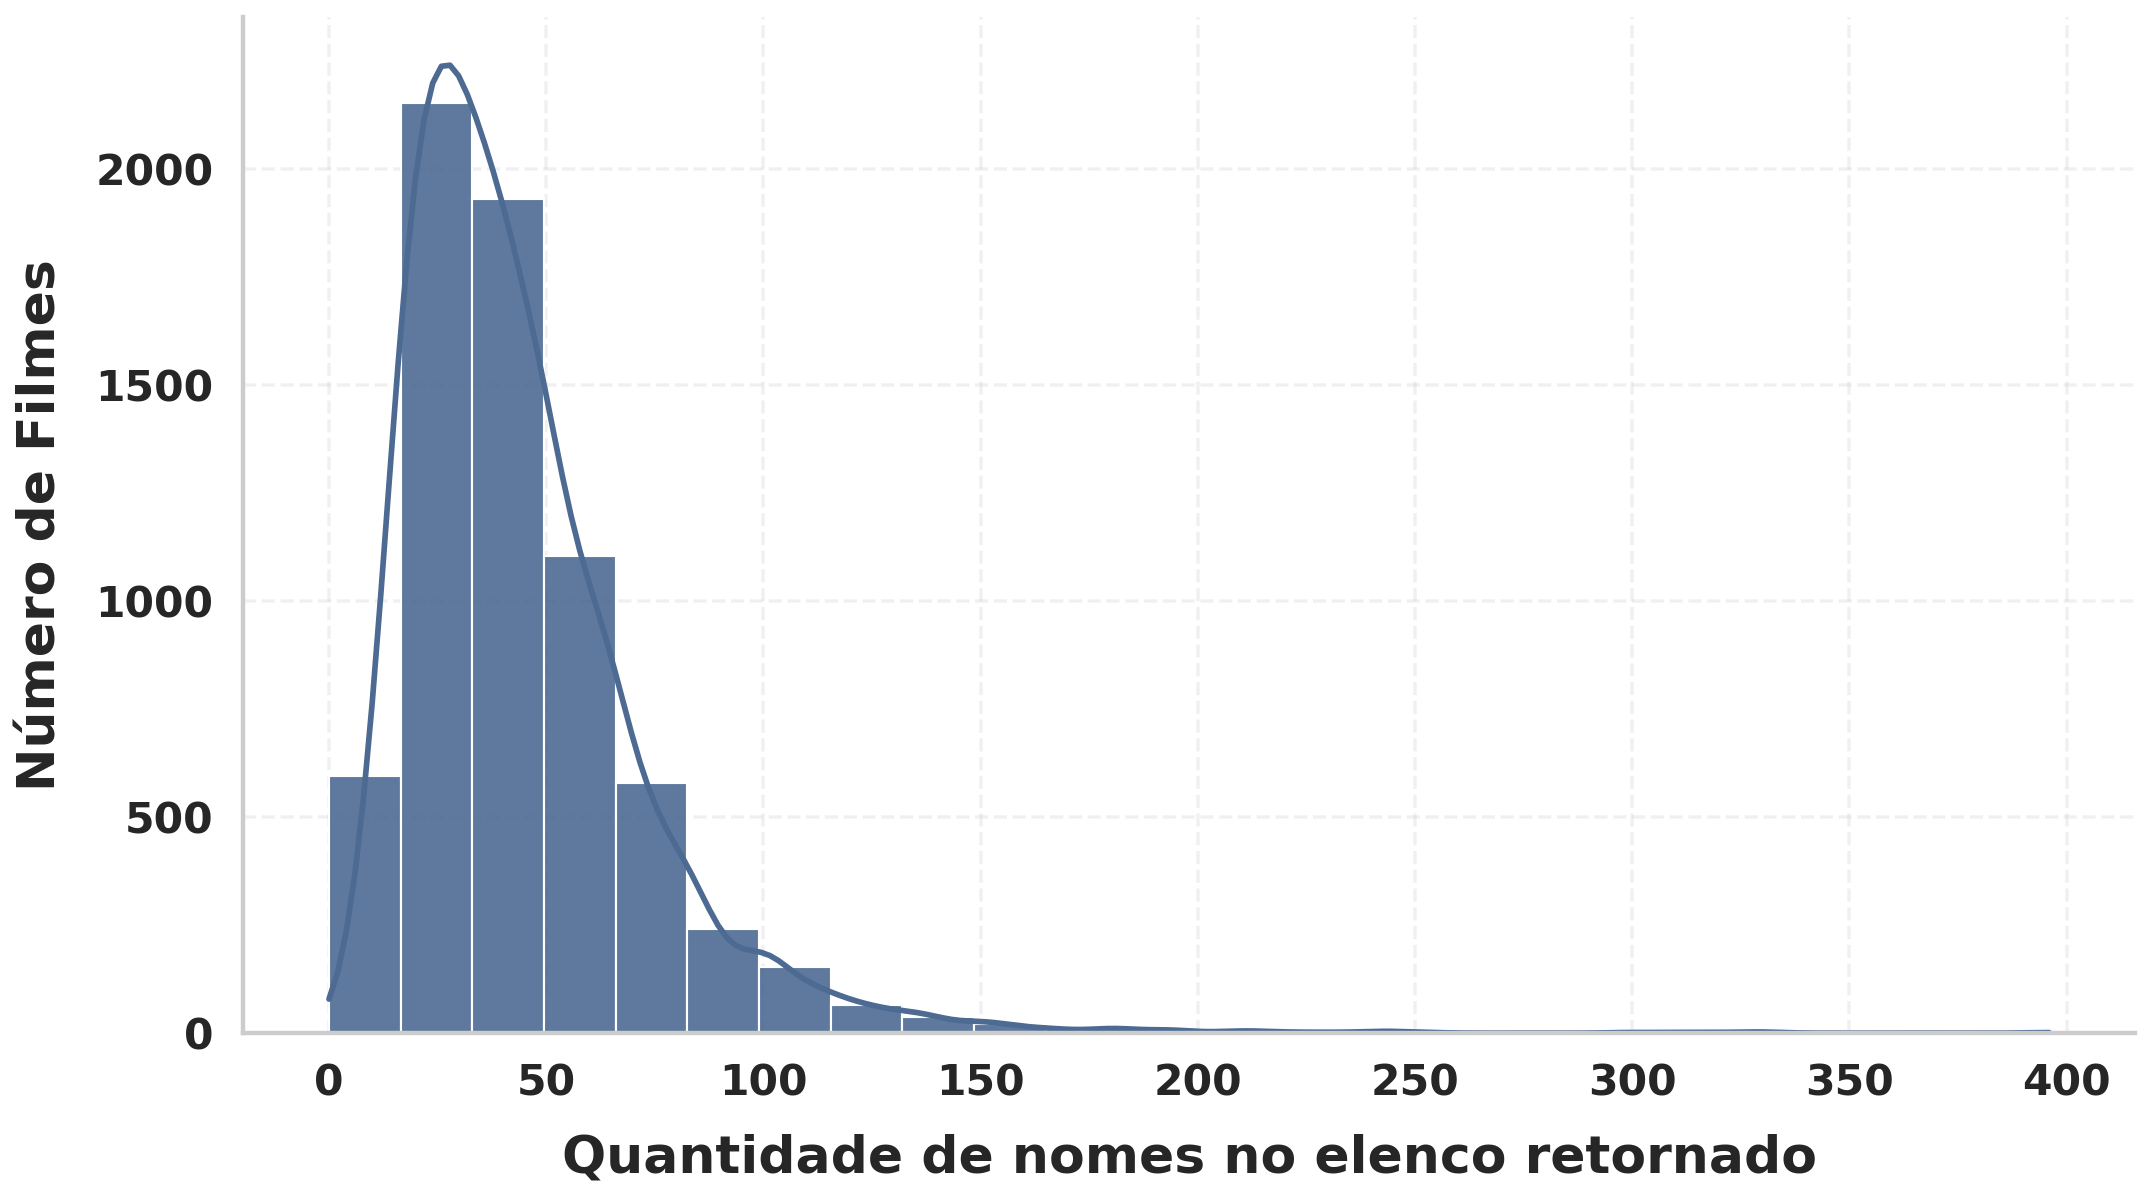

/tmp/ipykernel_7198/2171110284.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


Figura: Diretores Mais Frequentes na Base


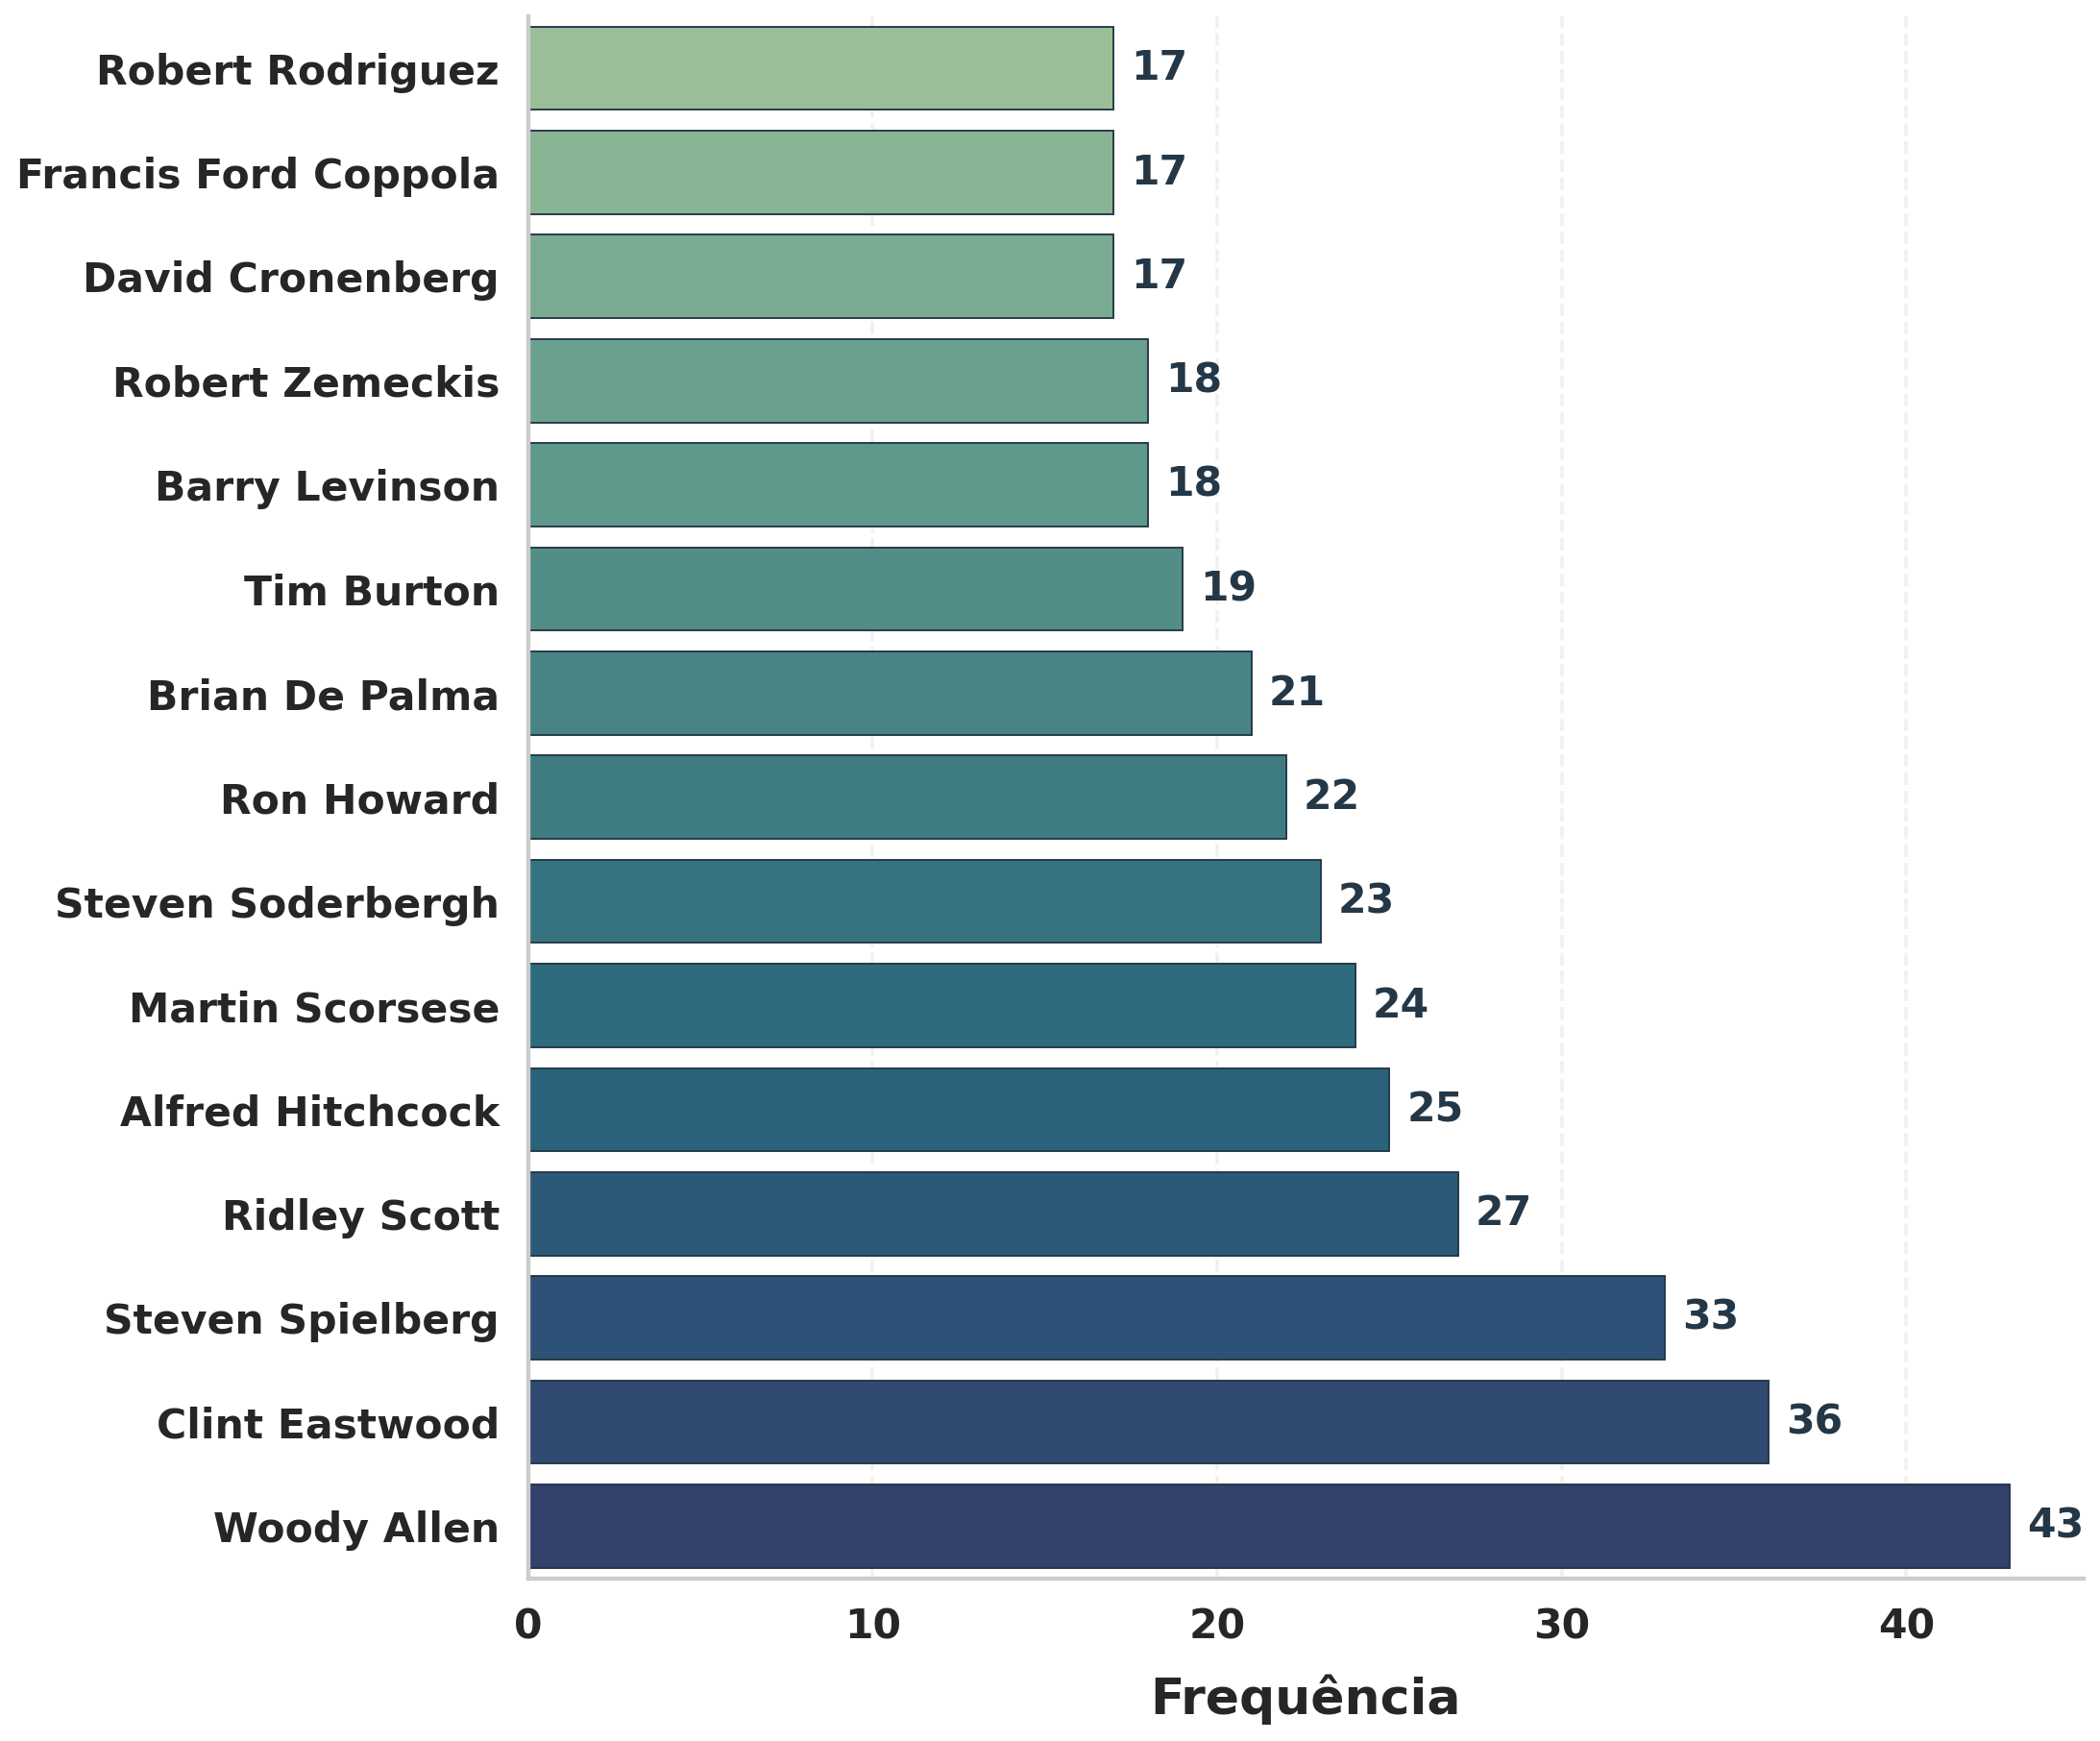

,director,frequencia
0,Robert Rodriguez,17
1,Francis Ford Coppola,17
2,David Cronenberg,17
3,Robert Zemeckis,18
4,Barry Levinson,18
5,Tim Burton,19
6,Brian De Palma,21
7,Ron Howard,22
8,Steven Soderbergh,23
9,Martin Scorsese,24


/tmp/ipykernel_7198/2171110284.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


Figura: Empresas de Produção Mais Frequentes


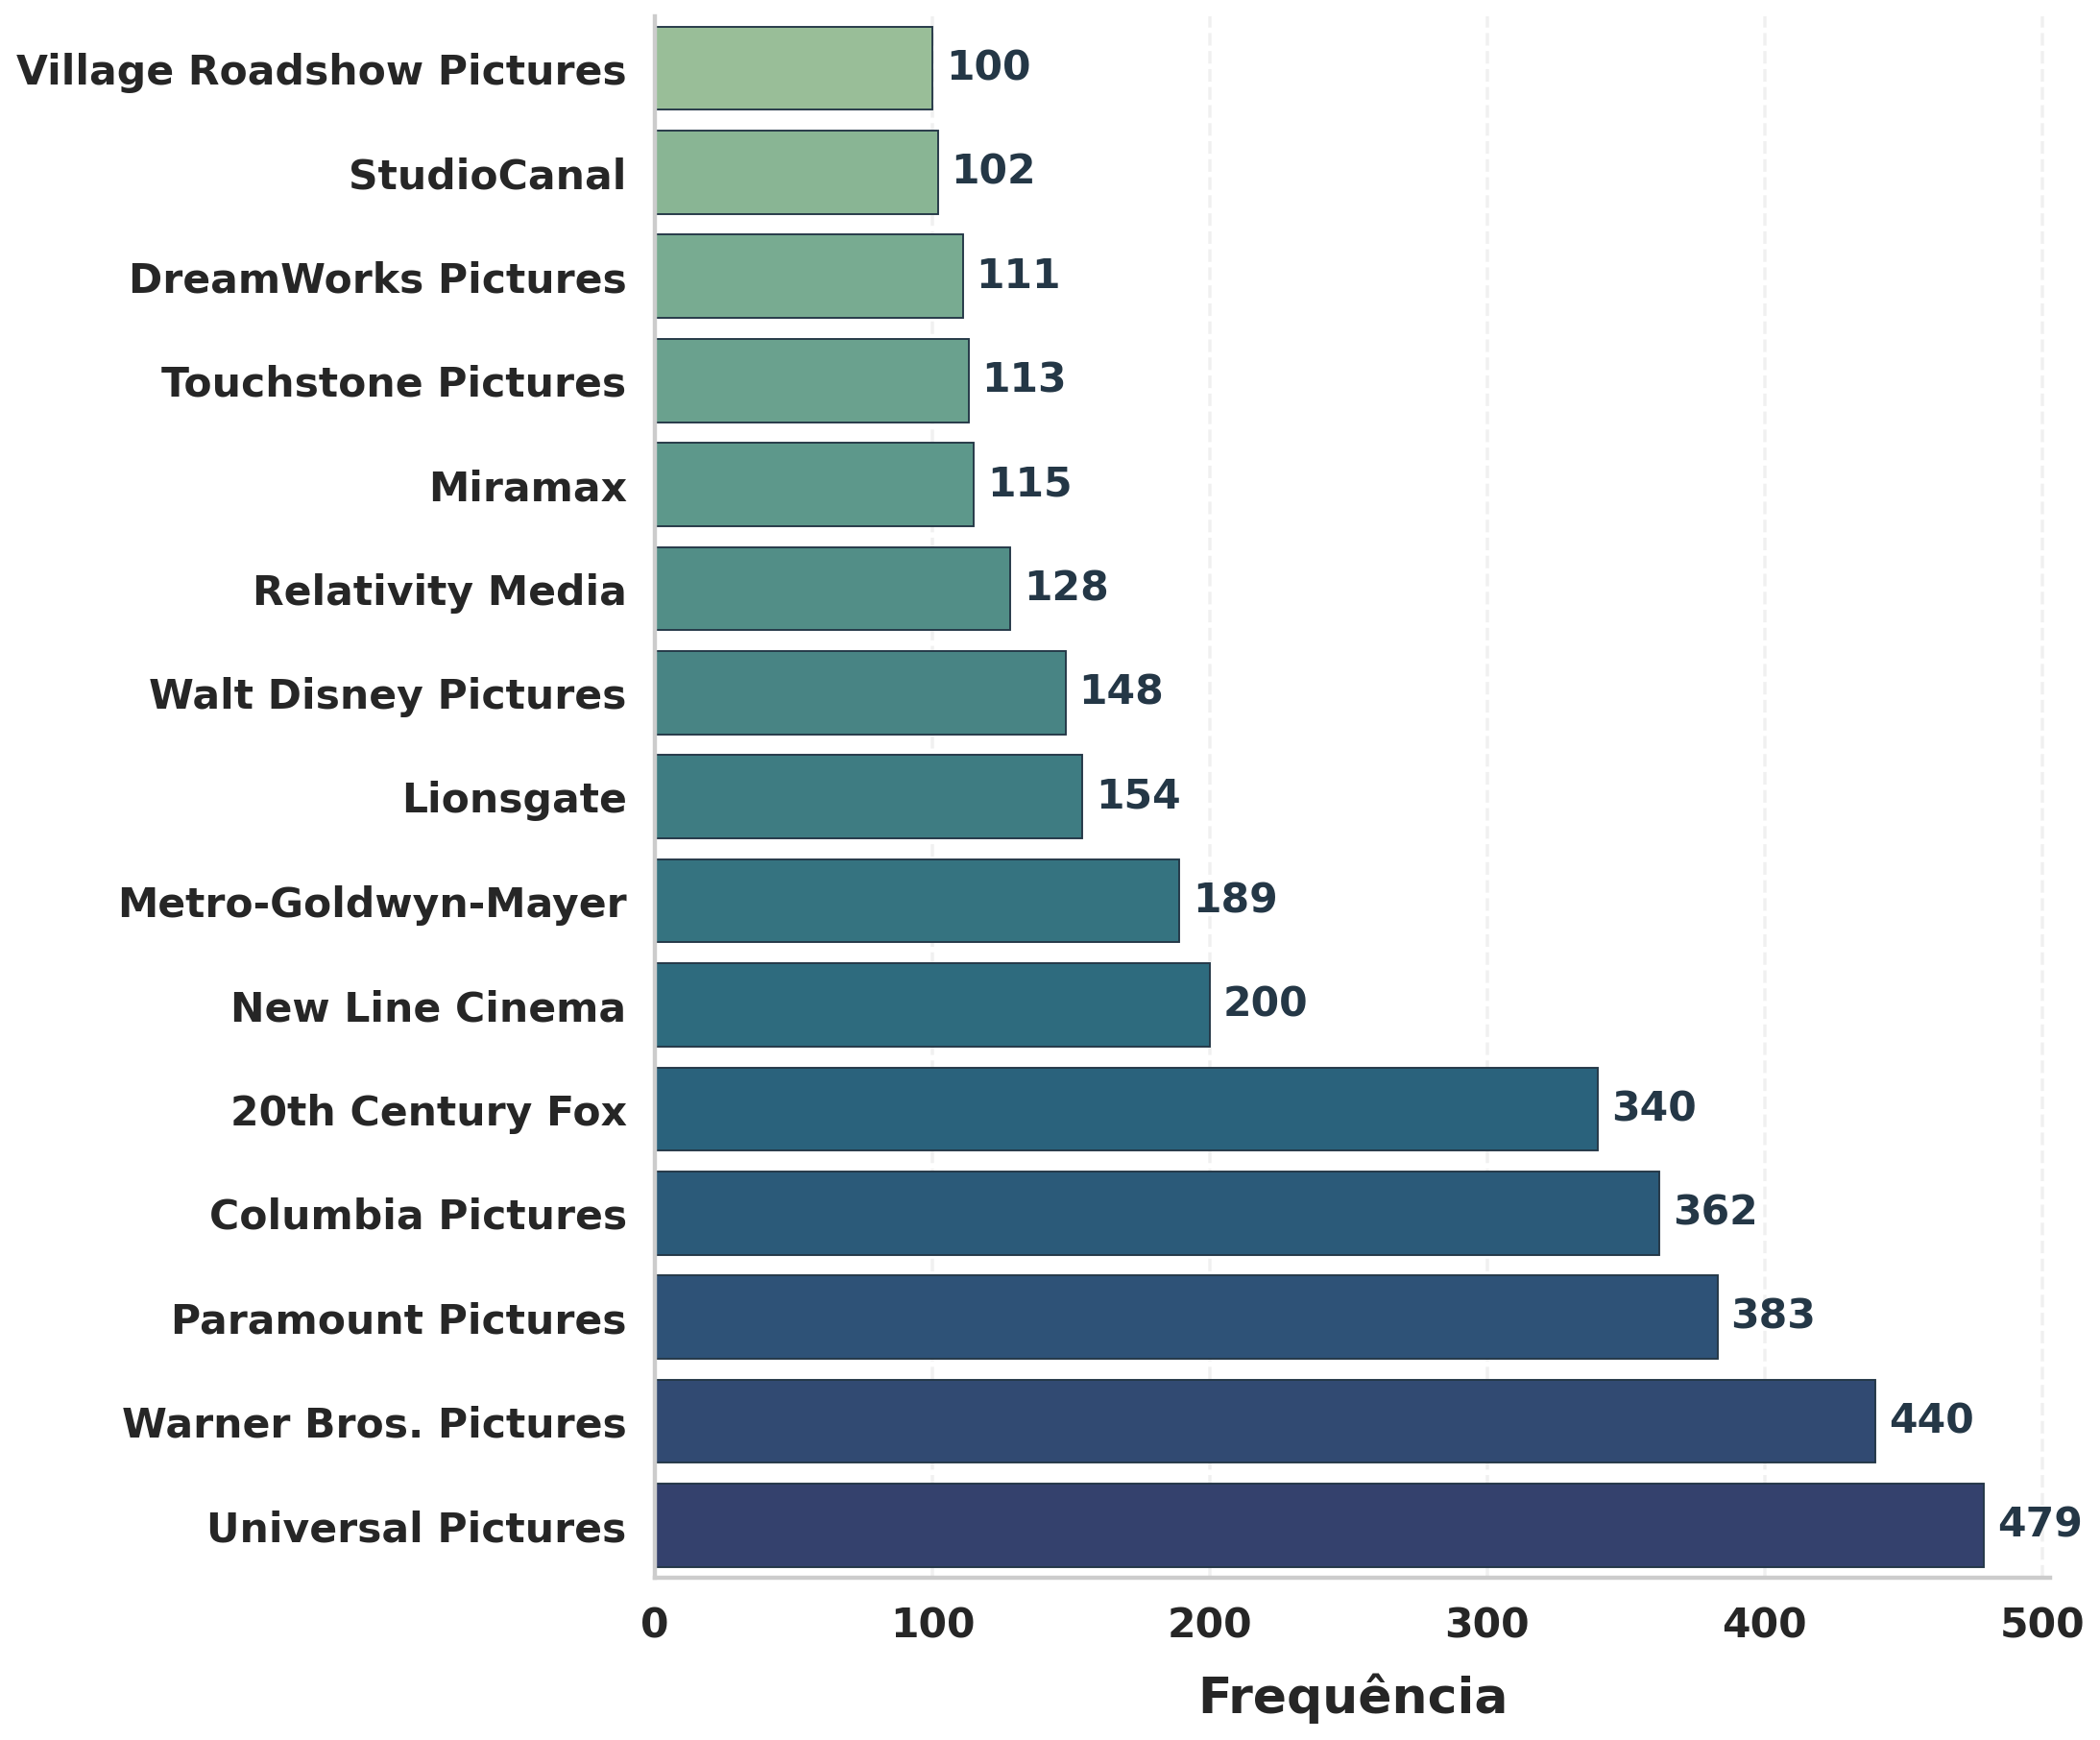

,production_company,frequencia
0,Village Roadshow Pictures,100
1,StudioCanal,102
2,DreamWorks Pictures,111
3,Touchstone Pictures,113
4,Miramax,115
5,Relativity Media,128
6,Walt Disney Pictures,148
7,Lionsgate,154
8,Metro-Goldwyn-Mayer,189
9,New Line Cinema,200


/tmp/ipykernel_7198/2171110284.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


Figura: Nomes de Elenco Mais Frequentes Entre os Créditos Principais


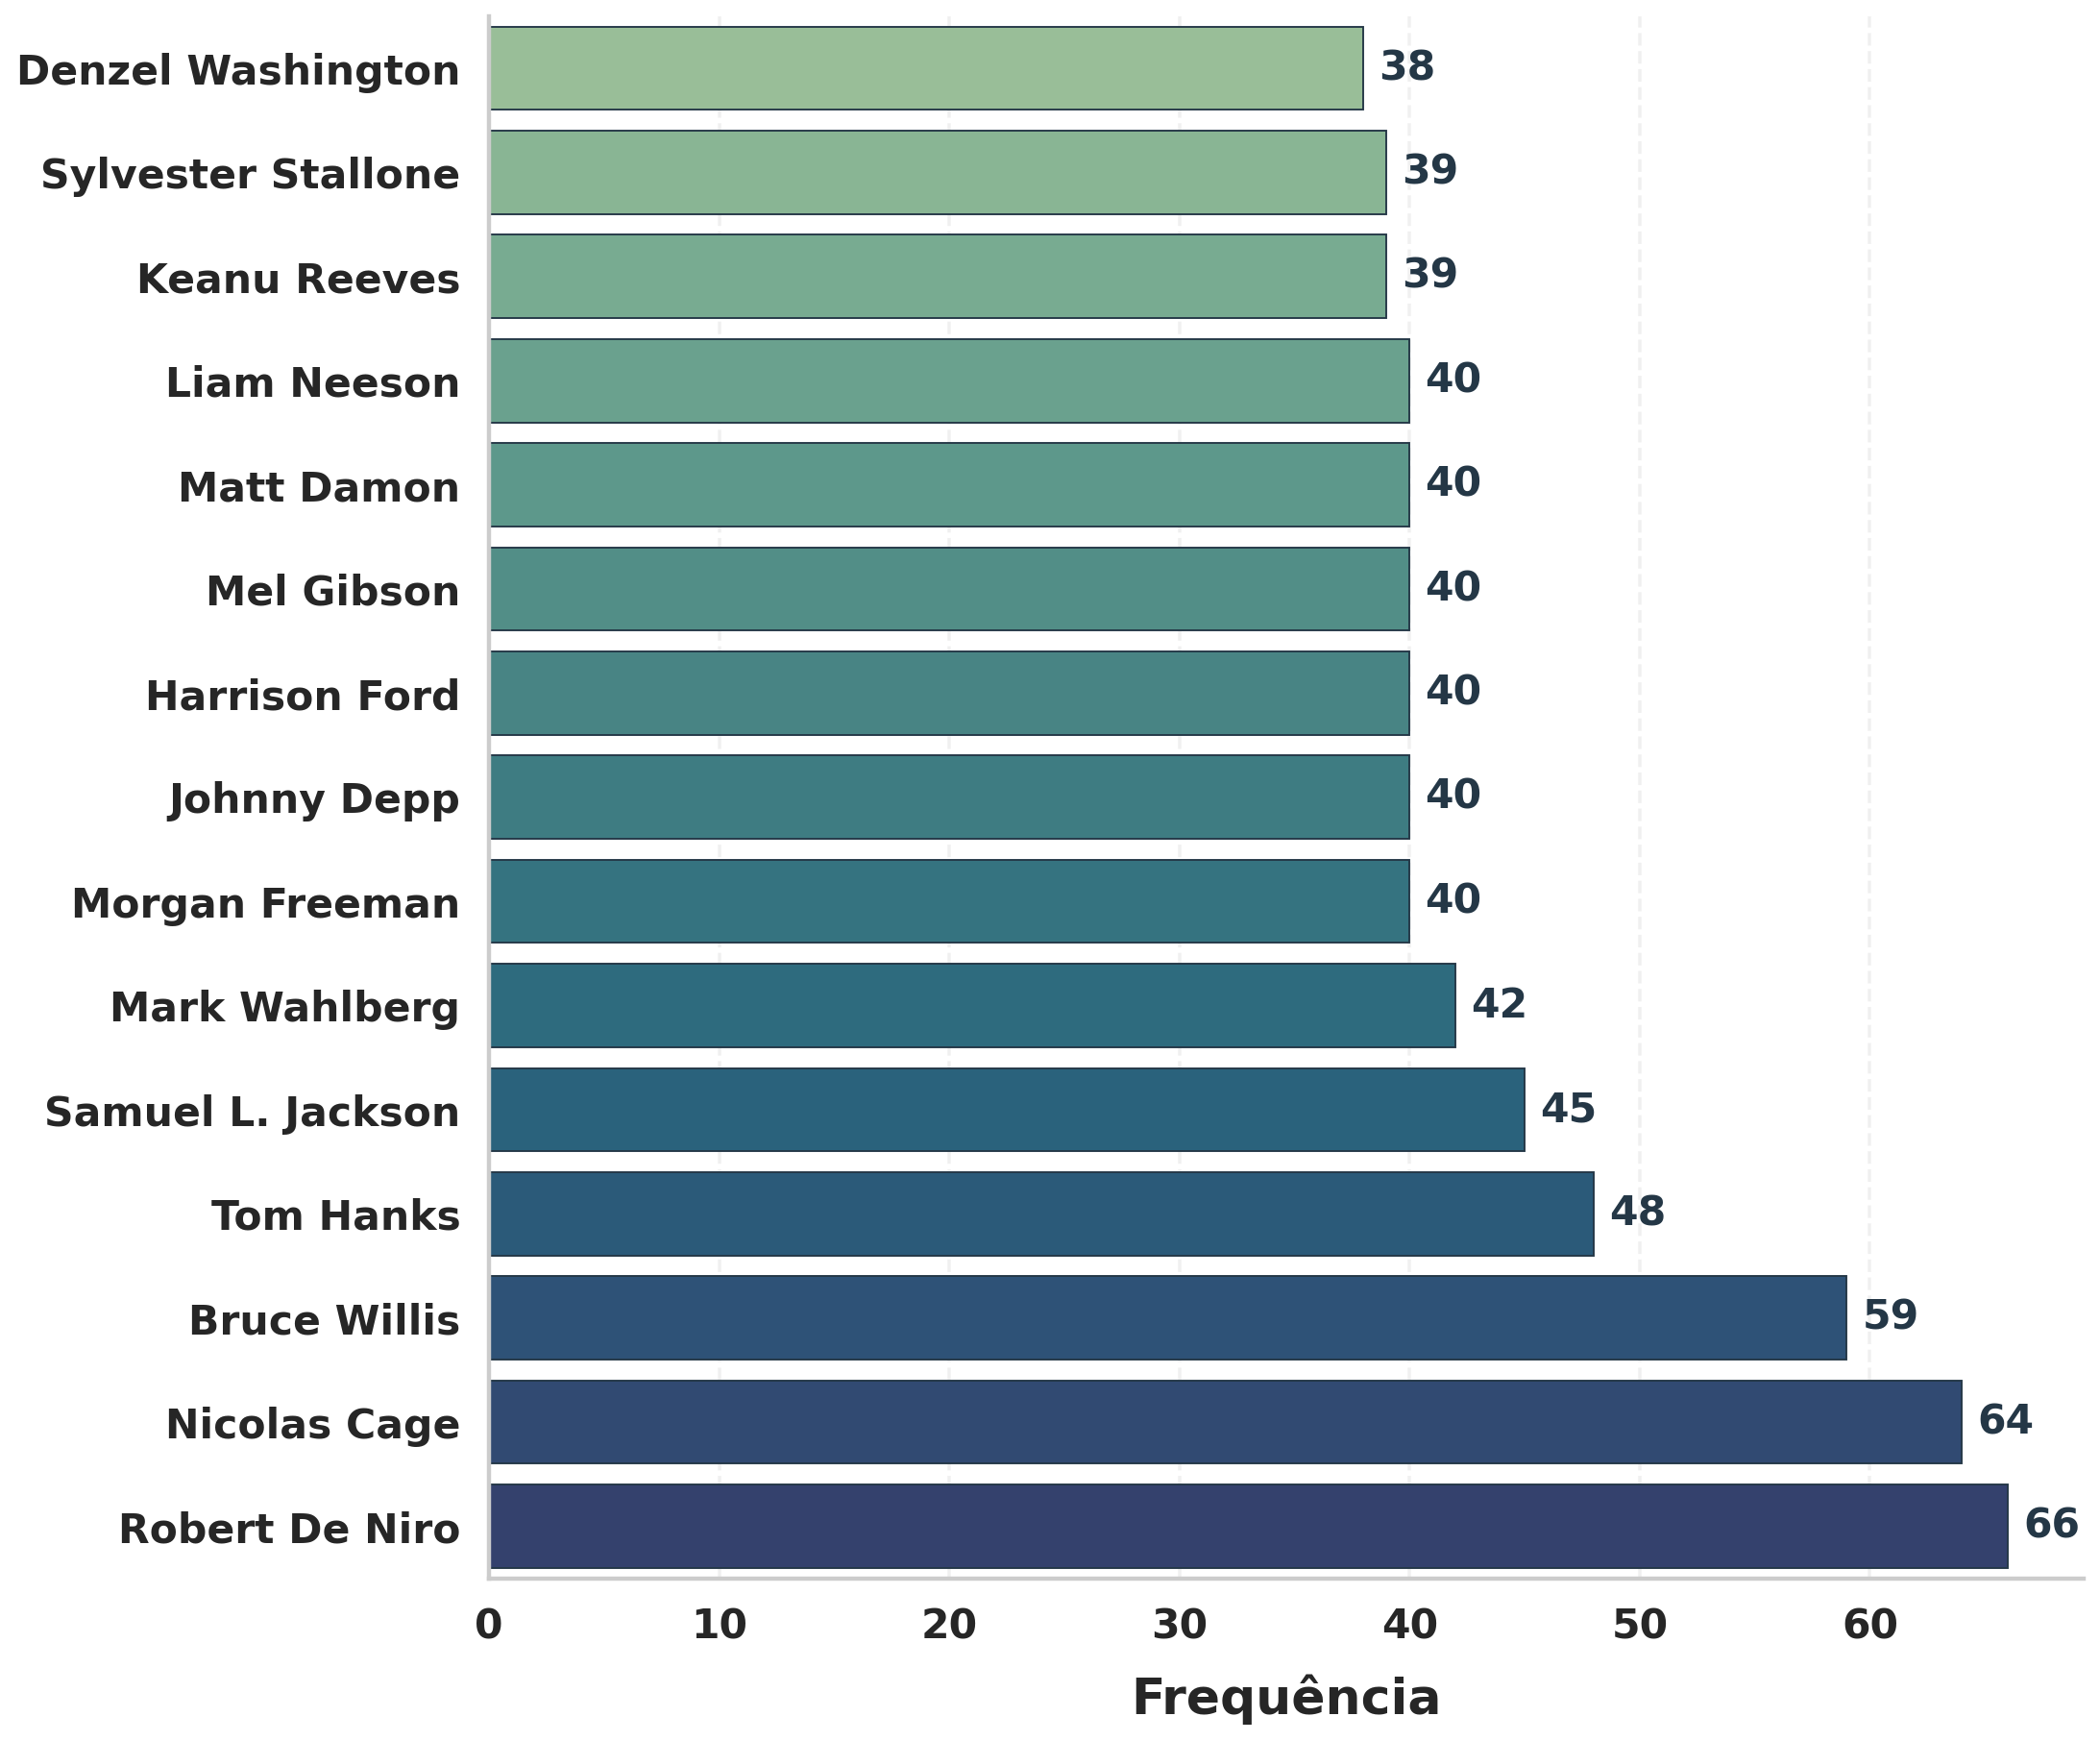

,cast_member,frequencia
0,Denzel Washington,38
1,Sylvester Stallone,39
2,Keanu Reeves,39
3,Liam Neeson,40
4,Matt Damon,40
5,Mel Gibson,40
6,Harrison Ford,40
7,Johnny Depp,40
8,Morgan Freeman,40
9,Mark Wahlberg,42


In [8]:
numeric_summary = analysis_df[
    ['production_company_count', 'cast_member_count', 'is_summer_release', 'is_holiday_release']
].describe().T
display(numeric_summary)

plot_numeric_distribution(
    analysis_df,
    column='production_company_count',
    title='Distribuição da Quantidade de Empresas de Produção',
    xlabel='Quantidade de empresas',
    filename='04_production_company_count_distribution.png',
)

plot_numeric_distribution(
    analysis_df,
    column='cast_member_count',
    title='Distribuição da Quantidade de Créditos no Elenco',
    xlabel='Quantidade de nomes no elenco retornado',
    filename='04_cast_member_count_distribution.png',
)

top_directors = plot_top_counts(
    analysis_df['director_name'],
    title='Diretores Mais Frequentes na Base',
    xlabel='Frequência',
    filename='04_top_directors.png',
)
display(top_directors.rename_axis('director').reset_index(name='frequencia'))

top_companies_series = pd.Series(
    [company for companies in analysis_df['company_list'] for company in companies],
    name='production_company'
)
top_companies = plot_top_counts(
    top_companies_series,
    title='Empresas de Produção Mais Frequentes',
    xlabel='Frequência',
    filename='04_top_production_companies.png',
)
display(top_companies.rename_axis('production_company').reset_index(name='frequencia'))

top_cast_series = pd.Series(
    [cast_member for cast_list in analysis_df['top_cast_list'] for cast_member in cast_list],
    name='cast_member'
)
top_cast_members = plot_top_counts(
    top_cast_series,
    title='Nomes de Elenco Mais Frequentes Entre os Créditos Principais',
    xlabel='Frequência',
    filename='04_top_cast_members.png',
)
display(top_cast_members.rename_axis('cast_member').reset_index(name='frequencia'))

# **Processando os metadados adicionais para regressão**

Nesta etapa final, as novas variáveis são codificadas e integradas à base processada original. O objetivo é obter um dataset estendido, com as colunas numéricas preservadas e as variáveis categóricas transformadas em indicadores binários para uso pelos modelos.

Assim como no notebook `02`, o escalonamento não é aplicado aqui. Ele continua sendo feito apenas dentro do pipeline de treinamento, evitando vazamento de informação.

In [9]:
tmdb_extended_df = merge_tmdb_additional_features_with_processed_dataset(
    processed_data_path=PROCESSED_DATA_INPUT,
    metadata_path=TMDB_METADATA_INPUT,
    output_path=TMDB_EXTENDED_PROCESSED_OUTPUT,
    top_cast_labels=TOP_CAST_LABELS,
    top_director_labels=TOP_DIRECTOR_LABELS,
    top_company_labels=TOP_COMPANY_LABELS,
)

print(tmdb_extended_df.shape)
display(tmdb_extended_df.head())

(6918, 287)


,id_tmdb,title,runtime,adult,belongs_to_collection,budget,Action,Adventure,Animation,Comedy,...,production_company_working_title_films,release_quarter_Q1,release_quarter_Q2,release_quarter_Q3,release_quarter_Q4,release_period_inverno,release_period_outono,release_period_primavera,release_period_verao,revenue
0,552524,Lilo & Stitch,108,0,0,100000000,0,0,0,1,...,0,False,True,False,False,False,True,False,False,610800000
1,950387,A Minecraft Movie,101,0,1,150000000,0,1,0,1,...,0,True,False,False,False,False,True,False,False,947000000
2,1257960,सिकंदर,133,0,0,23500000,1,0,0,0,...,0,True,False,False,False,False,True,False,False,24727058
3,574475,Final Destination Bloodlines,110,0,1,50000000,0,0,0,0,...,0,False,True,False,False,False,True,False,False,229314062
4,1197306,A Working Man,116,0,0,40000000,1,0,0,0,...,0,True,False,False,False,False,True,False,False,98652557


In [10]:
new_columns = [column for column in tmdb_extended_df.columns if column not in processed_df.columns]
print(f'Total de novas colunas TMDB: {len(new_columns)}')
display(pd.Series(new_columns[:120], name='novas_features_tmdb'))
print(f'Base estendida salva em: {TMDB_EXTENDED_PROCESSED_OUTPUT}')

Total de novas colunas TMDB: 214


0                  release_year
1                 release_month
2      production_company_count
3             cast_member_count
4             is_summer_release
                 ...           
115    cast_matthew_mcconaughey
116             cast_mel_gibson
117           cast_meryl_streep
118          cast_michael_caine
119        cast_michael_douglas
Name: novas_features_tmdb, Length: 120, dtype: object

Base estendida salva em: /home/gabriel/Faculdade/Matérias/ML/UFSJ_Aprendizado_Maquina_TP1/data/TMDB_movies_processed_tmdb_extended.csv
